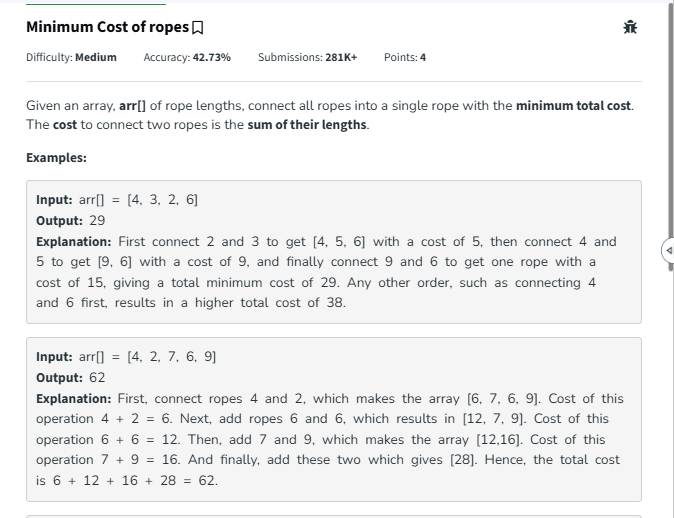
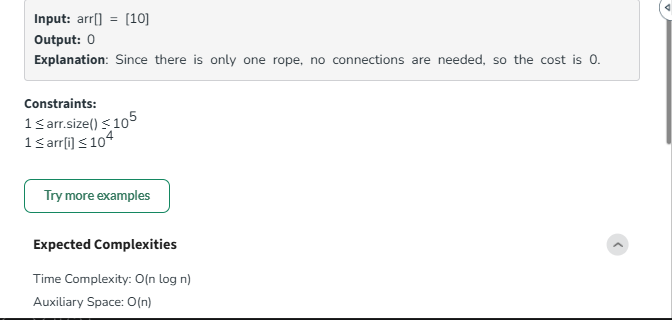

Core Logic
The algorithm solves the Minimum Cost to Connect Ropes problem using a greedy approach with a min-heap:

Key Principle: Always connect the two shortest ropes first.  This minimizes total cost because shorter ropes get added to the total cost more frequently than longer ones (similar to Huffman coding). 

Algorithm Steps:

Convert the array into a min-heap to efficiently access the smallest elements
While more than one rope remains:

Extract the two smallest ropes

Connect them (cost = sum of their lengths)

Add this cost to the total

Insert the combined rope back into the heap

Return the accumulated total cost 

Time Complexity: O(n log n)

Space Complexity: O(n)

Dry Run (Tabular Format)
Let's trace the code with input: arr = [4, 3, 2, 6]

| Iteration | Heap Before (sorted) | item1 (min) | item2 (2nd min) | add (item1+item2) | Heap After Push | cost (cumulative) |
|:---------:|:---------------------:|:-----------:|:---------------:|:-----------------:|:---------------:|:-----------------:|
| Initial   | [2, 3, 4, 6]         | -           | -               | -                 | -               | 0                 |
| 1         | [2, 3, 4, 6]         | 2           | 3               | 5                 | [4, 5, 6]       | 5                 |
| 2         | [4, 5, 6]            | 4           | 5               | 9                 | [6, 9]          | 5 + 9 = **14**    |
| 3         | [6, 9]               | 6           | 9               | 15                | [15]            | 14 + 15 = **29**  |

In [ ]:
import heapq
class Solution:
   def minCost(self, arr):
    # code here
    n = len(arr)
    heapq.heapify(arr)
    # ans = 0
    add = 0
    cost = 0
    for i in range(n - 1):
        item1 = heapq.heappop(arr)
        item2 = heapq.heappop(arr)
        add = item1 + item2
        heapq.heappush(arr, add)
        # print(item1, item2, add)
        # ans += item
        # n = len(arr)
        cost += add
    # print(arr)
    # print(cost)
    # final = heapq.heappop(arr)
    # return final
    return cost
    
    
    

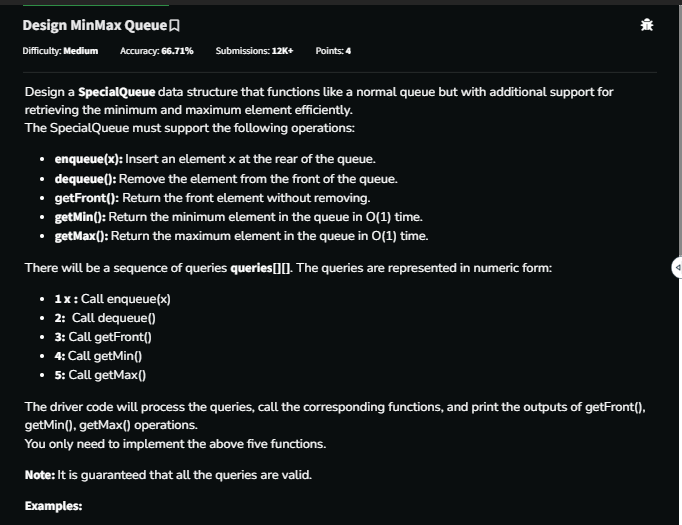
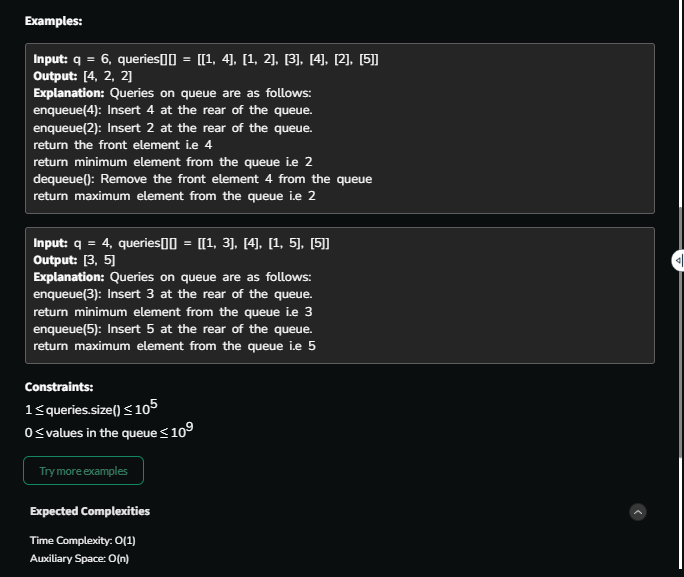

Dry Run Table

Input Sequence: enqueue(3), enqueue(1), enqueue(4), enqueue(2), dequeue(), dequeue()

| Operation | `q1` (Main Queue) | `q2` (Min Candidates) | `q3` (Max Candidates) | Current Min | Current Max |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Init** | `[]` | `[]` | `[]` | - | - |
| `enqueue(3)` | `[3]` | `[3]` | `[3]` | 3 | 3 |
| `enqueue(1)` | `[3, 1]` | `[1]` *(3 popped)* | `[3, 1]` | 1 | 3 |
| `enqueue(4)` | `[3, 1, 4]` | `[1, 4]` | `[4]` *(1, 3 popped)* | 1 | 4 |
| `enqueue(2)` | `[3, 1, 4, 2]` | `[1, 2]` *(4 popped)* | `[4, 2]` | 1 | 4 |
| `dequeue()` (rem 3) | `[1, 4, 2]` | `[1, 2]` *(no change)* | `[4, 2]` *(no change)* | 1 | 4 |
| `dequeue()` (rem 1) | `[4, 2]` | `[2]` *(1 popped)* | `[4, 2]` *(no change)* | 2 | 4 |

In [ ]:
from collections import deque

class SpecialQueue:
    def __init__(self):
        # Define Queue Data Structures
        self.q1 = deque() # Normal Queue
        self.q2 = deque() # Ascending Queue
        self.q3 = deque() # Descending Queue
    
    def enqueue(self, x):
        # Insert element into the queue
        self.q1.append(x)
        
        # Insert into Ascending Queue
        while self.q2 and self.q2[-1] > x:
            self.q2.pop()
        self.q2.append(x)
        
        # Insert into Desending Queue
        while self.q3 and self.q3[-1] < x:
            self.q3.pop()
        self.q3.append(x)
    
    def dequeue(self):
        # Remove element from the queue
        item = self.q1.popleft()
        # print(item)
        
        if self.q2 and self.q2[0] == item:
            self.q2.popleft()
        
        if self.q3 and self.q3[0] == item:
            self.q3.popleft()

    
    def getFront(self):
        # Get front element
        return self.q1[0] 
    
    def getMin(self):
        # Get minimum element
        return self.q2[0]
    
    def getMax(self):
        # Get maximum element
        return self.q3[0]


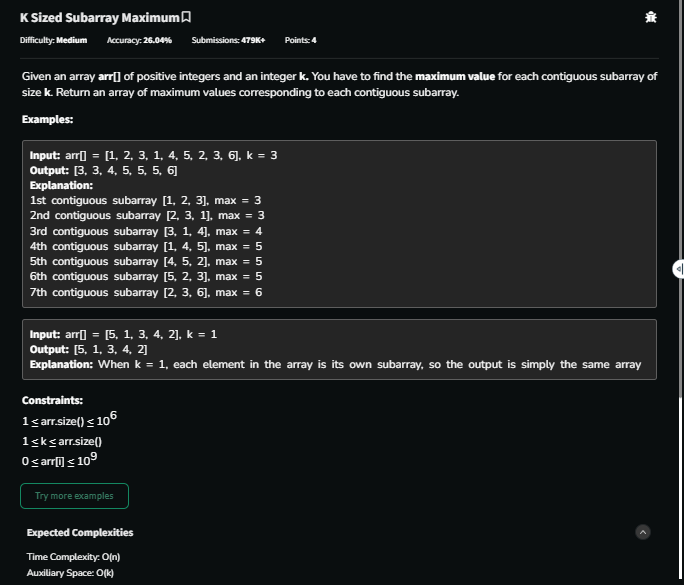

In [ ]:
from collections import deque

class Solution:
    def maxOfSubarrays(self, arr, k):
        # code here
        n = len(arr)

        # Initialize a max_queue to store indexes
        q = deque() 
        
        ans = []
        
        for i in range(n):
            # check if max element lies in the current window
            if q and q[0] <= i - k:
                q.popleft()
            
            # add new element to the max_queue
            while q and arr[q[-1]] < arr[i]:
                q.pop()
            q.append(i)
            
            # start pushing the max element from the queue into the ans
            if i >= k - 1:
                ans.append(arr[q[0]])
                
        return ans
            
            

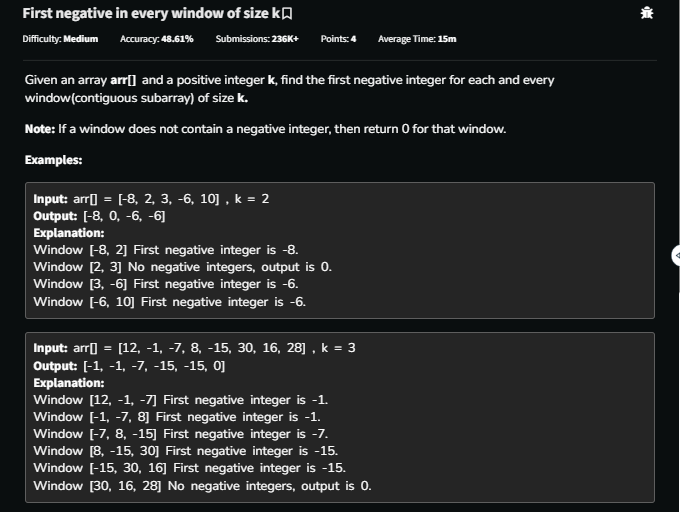
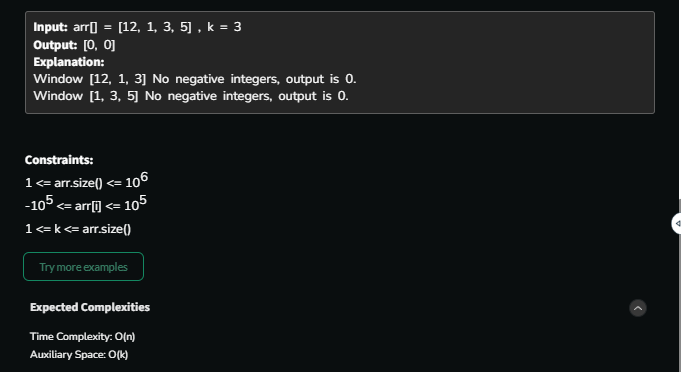

In [ ]:
from collections import deque

class Solution:
    def firstNegInt(self, arr, k):
        n = len(arr)
        ans = []
        q = deque()
        
        for i in range(n):
            # Add index of negative number to queue
            if arr[i] < 0:
                q.append(i)
            
            # Remove index if it's out of the current window
            if q and q[0] <= i - k:
                q.popleft()
            
            # Once we have processed at least k elements
            if i >= k - 1:
                if q:
                    ans.append(arr[q[0]])  # First negative in window
                else:
                    ans.append(0)  # No negative number in window
        
        return ans   